In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")  
sys.path.insert(0, PROJECT_ROOT)

# mainīgie
data_csv = os.path.join(PROJECT_ROOT, "data/raw/A_K_aukstais_udens.csv")

time_column_name = 'timestamp_unix'
value_column_name = 'value'
datetime_column_name = 'ts'


from src.prepare_data import(
    prepare_data,
    preprocess_data,
    day_use_dataset,
)
from src.anomaly_detection_algorithms.dspot import (
    DriftStreamingPeakOverThreshold,
    create_dspot_labeled_dataset
)
from src.visualizations import visualize_dspot
from src.labeling_dataset import(
artificial_leakage,
extract_over_threshold_only
)

In [2]:
import pandas as pd
data_csv = os.path.join(PROJECT_ROOT, "data/preprocessed/daily_usage_original.csv")
days_df = pd.read_csv(data_csv)
days_df = days_df.copy()
days_df

,date,delta
0,2024-01-01,0.579900
1,2024-01-02,0.690000
2,2024-01-03,0.670100
3,2024-01-04,0.790000
4,2024-01-05,0.690000
...,...,...
361,2024-12-27,0.621522
362,2024-12-28,0.552853
363,2024-12-29,0.535725
364,2024-12-30,0.627818


In [4]:
leaked_df = artificial_leakage(
    days_df,
    "2024-03-12",
    "2024-03-15",
    0.2
)
leaked_df

,date,delta
0,2024-01-01,0.579900
1,2024-01-02,0.690000
2,2024-01-03,0.670100
3,2024-01-04,0.790000
4,2024-01-05,0.690000
...,...,...
361,2024-12-27,0.621522
362,2024-12-28,0.552853
363,2024-12-29,0.535725
364,2024-12-30,0.627818


In [5]:
labeled_df = leaked_df.copy()

labeled_df["anomaly"] = (
    (labeled_df["delta"] > 0.8) |
    (labeled_df["date"].between("2024-03-12", "2024-03-15"))
)


In [6]:

output_path = os.path.join(PROJECT_ROOT, "data/labeled")
labeled_df.to_csv(os.path.join(output_path, "labeled_df_leak_march.csv"), index=False)

In [167]:
data = leaked_df["delta"].to_numpy()
# PARAMETERS 
num_init = 36
depth = 6

threshold = DriftStreamingPeakOverThreshold(
    data=data,
    num_init=num_init,
    depth=depth,
    num_candidates=10,
    risk=1e-4,
    init_level=0.93,
    epsilon=1e-8,
)

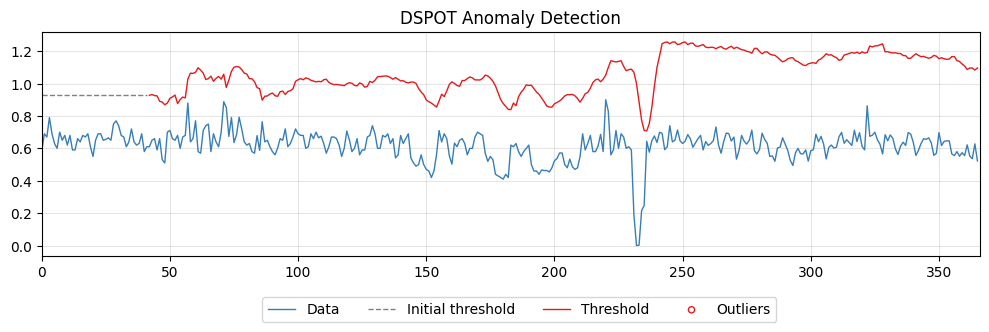

In [168]:
visualize_dspot (
    data = data,
    threshold = threshold,
    num_init = num_init,
    depth = depth,
    title ="DSPOT Anomaly Detection"
)

In [6]:
threshold

array([0.8462056 , 0.8462056 , 0.8462056 , 0.8462056 , 0.8462056 ,
       0.8462056 , 0.8462056 , 0.8462056 , 0.8462056 , 0.8462056 ,
       0.8462056 , 0.8462056 , 0.8462056 , 0.8462056 , 0.8462056 ,
       0.8462056 , 0.8462056 , 0.8462056 , 0.8462056 , 0.8462056 ,
       0.8462056 , 0.8462056 , 0.8462056 , 0.8462056 , 0.8462056 ,
       0.8462056 , 0.8462056 , 0.8462056 , 0.8462056 , 0.8462056 ,
       0.8462056 , 0.8462056 , 0.8462056 , 0.8462056 , 0.8462056 ,
       0.8462056 , 0.8462056 , 0.8462056 , 0.8462056 , 0.8462056 ,
       0.8462056 , 0.8462056 , 0.8462056 , 0.8462056 , 0.8462056 ,
       0.8462056 , 0.8462056 , 0.8462056 , 0.8462056 , 0.8462056 ,
       0.8462056 , 0.8462056 , 0.85153893, 0.84887227, 0.84953227,
       0.83687227, 0.83553893, 0.83887893, 0.8575456 , 0.85353893,
       0.87221347, 0.87822681, 0.87555347, 0.86821347, 0.87622014,
       0.88621347, 0.89221347, 0.88689347, 0.88956014, 0.88689347,
       0.88755347, 1.03806125, 1.05192792, 1.04058792, 1.03534

In [7]:
import pandas as pd
import numpy as np


labeled_df = create_dspot_labeled_dataset(
    leaked_df,
    threshold
)

In [8]:
labeled_df

,date,delta,over_threshold
0,2024-01-01,0.579900,False
1,2024-01-02,0.690000,False
2,2024-01-03,0.670100,False
3,2024-01-04,0.790000,False
4,2024-01-05,0.690000,False
...,...,...,...
361,2024-12-27,0.621522,False
362,2024-12-28,0.552853,False
363,2024-12-29,0.535725,False
364,2024-12-30,0.627818,False


In [9]:
anomalies_df = extract_over_threshold_only(labeled_df)

In [10]:
anomalies_df

,date,delta,over_threshold
57,2024-02-27,0.8800,True
220,2024-08-08,0.9001,True
245,2024-09-02,0.7400,True
